## **Music Recommendation Algorithm Project**
</br>
Info here

***Model***

Details

---
### **1. Imports**

In [1]:
# Importing sys to ensure proper environment setup
import sys

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, pylab
from matplotlib.legend import Legend
import statistics
from scipy.stats import skew, kurtosis, trim_mean
import seaborn as sns
import os # possibly remove
from pathlib import Path, PureWindowsPath
from scipy.stats import multivariate_normal, norm, trim_mean, zscore
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn items for preprocessing, model training & testing
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, Normalizer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, classification_report, silhouette_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

from kneed import KneeLocator, DataGenerator, find_shape
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Different label assignment (assign_labels="cluster_qr") as deterministic partitioning alternative
from sklearn.cluster import KMeans, AffinityPropagation, DBSCAN, SpectralClustering
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Makes graphs appear in line
%matplotlib inline

sns.set(style="whitegrid", palette="Set3", font_scale=1.25)    # alt muted, spectral, tab20c

print("Setup Complete")

Setup Complete


---
### **2. Load Data & Quick Review**

In [3]:
# Explicitly noting path as being in Windows format to avoid issues with backsplash
#filename = PureWindowsPath("..Data\tcc_ceds_music.csv")

# Convert path to the correct format
#file_path = Path(filename)
rec_test = open("C:\\Users\\winni\\music-rec-algo\\Data\\rec_clean_test.csv")
clean_a = open("C:\\Users\\winni\\music-rec-algo\\Data\\clean_a1.csv")

# Loading data as a DataFrame
df_rec_test = pd.read_csv(rec_test) 
df_clean_a = pd.read_csv(clean_a)

# Using head() function to display the first five rows of the data
print("Heads")
print("Recommendation Test Data:", df_rec_test.head())
print("Cleaned Data:", df_clean_a.head())

Heads
Recommendation Test Data:         artist_name           track_name  release_date    dating  violence  \
0          godsmack               immune      0.859742 -0.418129  0.688735   
1      dennis brown        second chance      0.584184 -0.412965 -0.696636   
2  the black crowes          sister luck      0.418849 -0.414664  1.273356   
3   jerry lee lewis  your cheating heart     -1.234502  2.907046 -0.816073   
4         paul anka             eso beso     -0.903832 -0.413852 -0.821892   

   world_life  night_time  shake_the_audience  family_gospel  romantic  ...  \
0    2.523982   -0.924201            2.958886      -0.507165 -0.389008  ...   
1   -0.790271    1.025128           -0.413514       0.457949  0.038872  ...   
2   -0.791193   -0.922847           -0.415081       2.837519 -0.387686  ...   
3   -0.778914   -0.102406           -0.394226      -0.459734 -0.379055  ...   
4   -0.790752   -0.609398           -0.414333       0.163963  2.976164  ...   

   genre_country  genre_

In [4]:
# Using shape() function to return a tuple listing number of rows and columns in the data

print("Shape of Rec Test:", df_rec_test.shape)
print("Shape of Clean Data:", df_clean_a.shape)

Shape of Rec Test: (10, 29)
Shape of Clean Data: (28372, 29)


In [5]:
# Using info() function to view column names, data types, and other relevant information

df_rec_test.info()

df_clean_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               10 non-null     object 
 1   track_name                10 non-null     object 
 2   release_date              10 non-null     float64
 3   dating                    10 non-null     float64
 4   violence                  10 non-null     float64
 5   world_life                10 non-null     float64
 6   night_time                10 non-null     float64
 7   shake_the_audience        10 non-null     float64
 8   family_gospel             10 non-null     float64
 9   romantic                  10 non-null     float64
 10  communication             10 non-null     float64
 11  obscene                   10 non-null     float64
 12  music                     10 non-null     float64
 13  movement_places           10 non-null     float64
 14  light_visual_

In [6]:
# Updating column names to remove whitespace and erroroneous characters on rec_test

df_rec_test.columns = df_rec_test.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(':', '')
df_rec_test.columns = df_rec_test.columns.str.replace(')', '').str.replace('-', '_').str.replace('/', '_')
print("Updated Column Names:", df_rec_test.columns)
print(df_rec_test.info())

Updated Column Names: Index(['artist_name', 'track_name', 'release_date', 'dating', 'violence',
       'world_life', 'night_time', 'shake_the_audience', 'family_gospel',
       'romantic', 'communication', 'obscene', 'music', 'movement_places',
       'light_visual_perceptions', 'family_spiritual', 'like_girls', 'sadness',
       'feelings', 'genre_country', 'genre_jazz', 'genre_pop', 'genre_reggae',
       'genre_rock', 'topic_obscene', 'topic_romantic', 'topic_sadness',
       'topic_violence', 'topic_world_life'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               10 non-null     object 
 1   track_name                10 non-null     object 
 2   release_date              10 non-null     float64
 3   dating                    10 non-null     float64
 4   violence          

In [7]:
# Creating copies of datasets for multiple model testings
df_cl = df_clean_a.copy()
df_rec = df_rec_test.copy()

# Dropping non-numeric columns as they're not needed for modeling
df_cl = df_cl.drop(columns=['artist_name', 'track_name'])
print("Cleaned Data after dropping non-numeric columns:\n", df_cl.head(5))

df_rec = df_rec.drop(columns=['artist_name', 'track_name'])
print("Recommendation Test Data after dropping non-numeric columns:\n", df_rec.head(5))

Cleaned Data after dropping non-numeric columns:
    release_date    dating  violence  world_life  night_time  \
0      -2.17648 -0.391712 -0.305855   -0.699056   -0.507401   
1      -2.17648  0.275459 -0.120996    1.872639   -0.501275   
2      -2.17648 -0.350237 -0.647112   -0.686443   -0.487995   
3      -2.17648  0.518198 -0.653951   -0.693540   -0.498914   
4      -2.17648 -0.377363 -0.655062    1.723607   -0.500687   

   shake_the_audience  family_gospel  romantic  communication   obscene  ...  \
0           -0.413684       0.758051 -0.297631       1.707845 -0.532651  ...   
1           -0.396826       0.237390 -0.446751      -0.688320 -0.528870  ...   
2           -0.360278      -0.340172  1.035725       1.588406 -0.520671  ...   
3            0.100271      -0.369294  3.420147      -0.685907 -0.527412  ...   
4           -0.395207      -0.374023  3.909285      -0.687719 -0.528507  ...   

   genre_country  genre_jazz  genre_pop  genre_reggae  genre_rock  \
0      -0.487332   -0

--- 
### **3. Feature Engineering: Train/Test/Split**

##### **<p style="text-align:center;">3A. The Body Beautiful: Elbow, Silhouette & More</p>**    
Performing primliminary clustering via the Elbow Method and related methologies.

In [8]:
# Setting these as X_train & rec
X_train = df_cl.copy()
X_rec = df_rec.copy()

In [9]:
# Dropping string columns
X_train = X_train.select_dtypes(include=[np.number])

X_rec = X_rec.select_dtypes(include=[np.number])

K1 Knee: 0.2222222222222222
K1 Kee Y: 1.8965517241379306
0.222
0.222
1.897


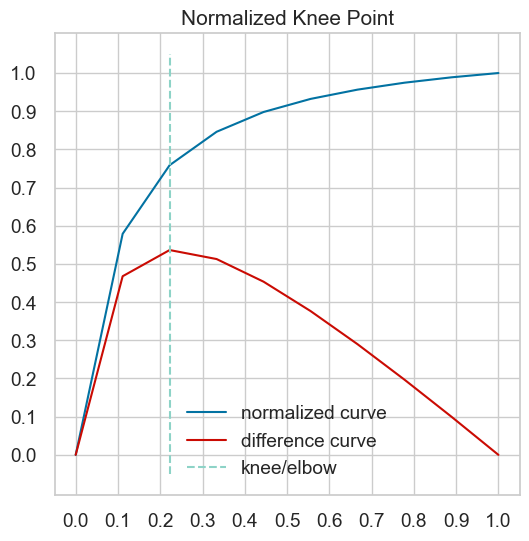

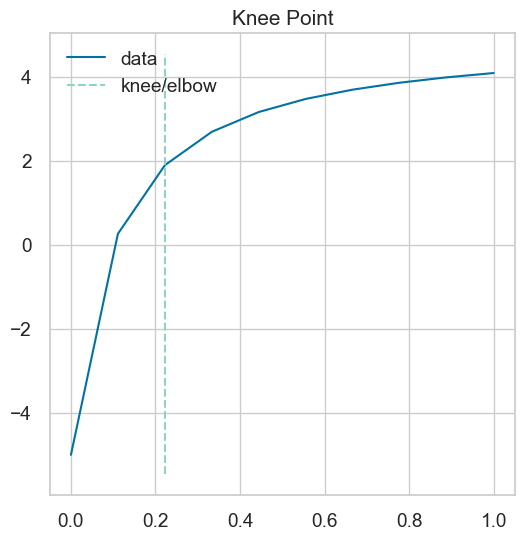

In [10]:
# Kneed sample generator & plotting

x, y = DataGenerator.figure2()

k1 = KneeLocator(x, y, curve="concave", direction="increasing")
print("K1 Knee:", k1.knee)
print("K1 Kee Y:", k1.knee_y)

# Alternative using find_shape to auto-detect curve type & direction
direction, curve = find_shape(x, y)
k1 = KneeLocator(x, y, curve=curve, direction=direction)

# Using kneedle.knee & kneedle.elbow to store maximum curvature points
kneedle = KneeLocator(x, y, S=1.0, curve="concave", direction="increasing")
print(round(kneedle.knee, 3))
print(round(kneedle.elbow, 3))

# Identifying the y value at the knee
print(round(kneedle.knee_y, 3))

# Normalized data, normalized knee, & normalized distance curve
kneedle.plot_knee_normalized()

# Raw data and knee
kneedle.plot_knee()

  k= 2  →  inertia = 701,020
  k= 3  →  inertia = 638,087
  k= 4  →  inertia = 582,159
  k= 5  →  inertia = 532,071
  k= 6  →  inertia = 492,068
  k= 7  →  inertia = 469,917
  k= 8  →  inertia = 452,221
  k= 9  →  inertia = 442,860
  k=10  →  inertia = 435,532
  k=11  →  inertia = 426,274
  k=12  →  inertia = 420,010
Inertia Score:
701019.5662503554
638087.4400677595
582159.3229087899
532071.4593609464
492067.6821020062
469916.73783774965
452220.7237645071
442860.41936397005
435532.329761274
426273.73163136333
420010.37835354556
KneeLocator Elbow Point: 6


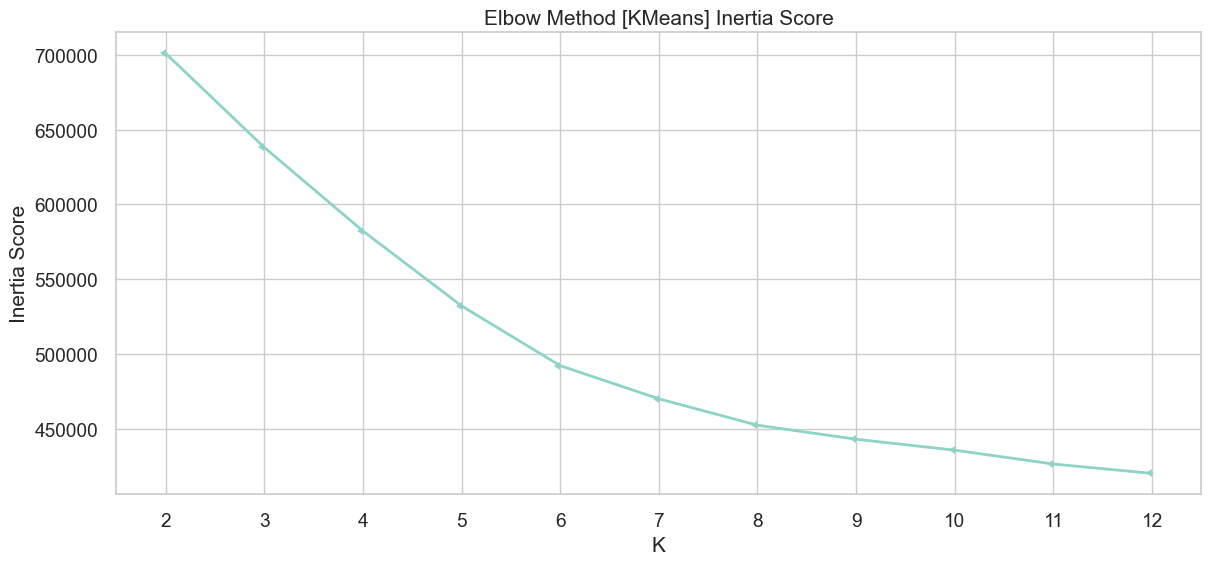

In [11]:
# Inertia score will be stored in this list
inertia_score = []

# Defining cluster values to test
# KMeans model testing 2-12 clusters
k_values = range(2, 13)

# Iterating for loop of cluster possibilities
for k in k_values:
    # Creating initial KMeans model with max # of clusters
    km = KMeans(
        n_clusters=k, 
        random_state=42, 
        n_init=12
        )

    # Fitting model on training feature matrix
    km.fit(X_train)

    # Beginning intertia score (how compact clusters are)
    inertia_score.append(km.inertia_)
    print(f"  k={k:2d}  →  inertia = {km.inertia_:,.0f}")

print("Inertia Score:")
list(map(print, inertia_score))

# Using KneeLocator as backup to identify elbow point of the curve programmatically
k1 = KneeLocator(range(2, 13), inertia_score, curve="convex", direction="decreasing")
k1.elbow
print("KneeLocator Elbow Point:", k1.elbow)

plt.figure(figsize=(14,6))

plt.plot(range(2, 13), inertia_score, linewidth=2, marker=8)
plt.title("Elbow Method [KMeans] Inertia Score")
plt.xlabel("K")
plt.ylabel("Inertia Score")
plt.xticks(range(2, 13))

# saving plot as image in docs folder
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\elbow_inertia.png", dpi=150)
plt.show()

  k= 2  →  inertia = 701,020
  k= 3  →  inertia = 638,087
  k= 4  →  inertia = 582,159
  k= 5  →  inertia = 532,071
  k= 6  →  inertia = 492,068
  k= 7  →  inertia = 469,917
  k= 8  →  inertia = 460,239
  k= 9  →  inertia = 442,860
  k=10  →  inertia = 435,532
  k=11  →  inertia = 426,655
  k=12  →  inertia = 420,010
Optimal K: 6
[1 0 5 ... 2 2 2]


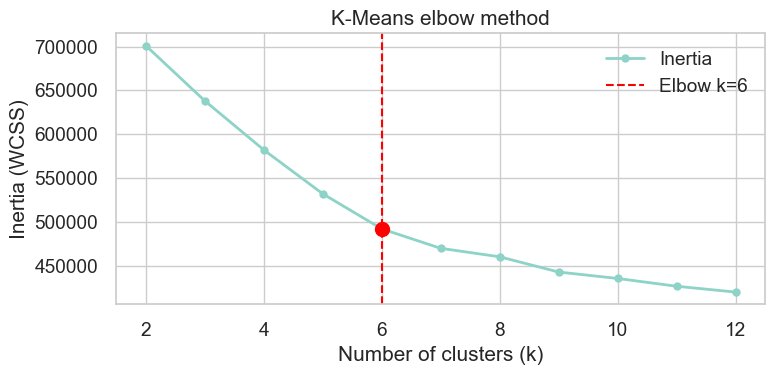

In [12]:
# Based on the inertia scores & KneeLocator elbow point, retraining and visualizing elbow method result

# --- Elbow method ---
K_RANGE = range(2, 13)
inertias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)          # X_train = numeric feature matrix
    inertias.append(km.inertia_)
    print(f"  k={k:2d}  →  inertia = {km.inertia_:,.0f}")

kl = KneeLocator(list(K_RANGE), inertias, curve="convex", direction="decreasing")
optimal_k = kl.elbow  # → 4
print("Optimal K:", optimal_k)

# --- Retrain final model ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(X_train)
labels = kmeans_final.labels_
print(labels)

# --- Elbow plot ---
plt.figure(figsize=(8, 4))
plt.plot(list(K_RANGE), inertias, marker="o", linewidth=2, label="Inertia")
plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Elbow k={optimal_k}")
plt.scatter([optimal_k], [inertias[optimal_k - 2]], color="red", zorder=5, s=100)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("K-Means elbow method")
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\elbow_plot_ok.png", dpi=150)
plt.show()

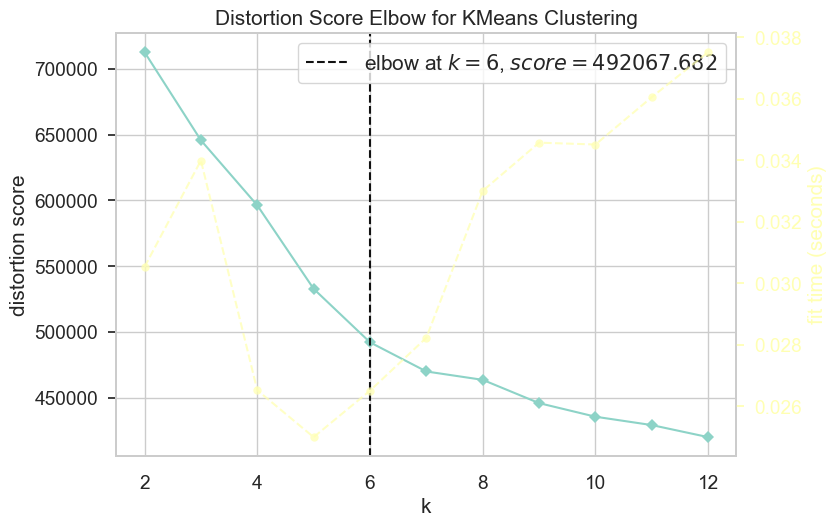

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [13]:
# Elbow Visualizer
km = KMeans(random_state=42)
visualizer = KElbowVisualizer(km, k=(2, 13))

visualizer.fit(X_train)
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\distort_elbow_plt.png", dpi=150)
visualizer.show()

[2 5 6 ... 3 3 3]


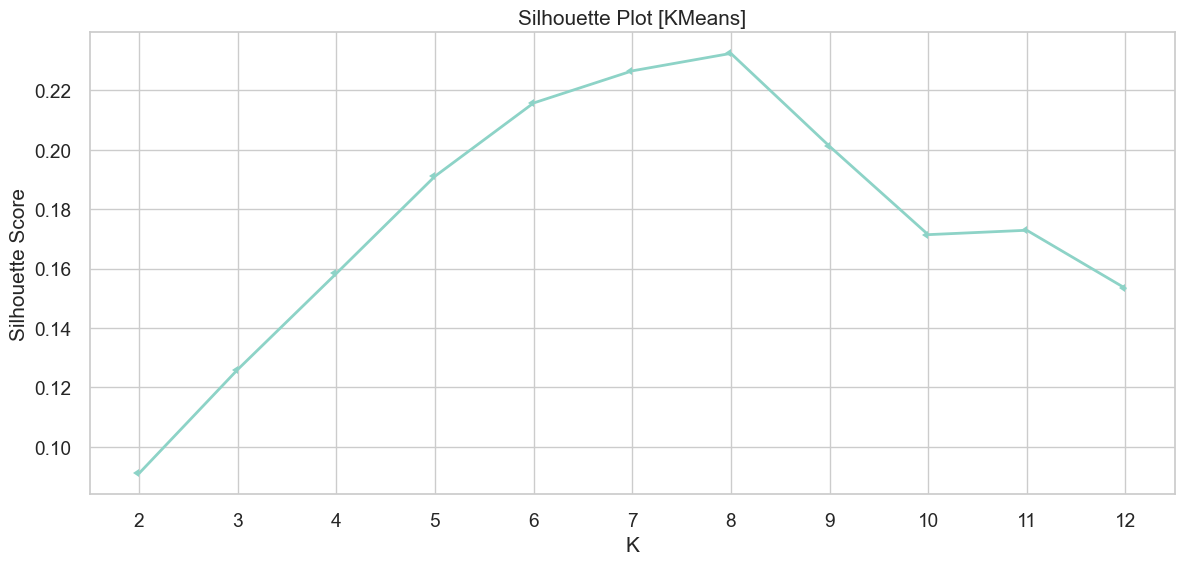

In [14]:
# Silhouette score will be stored in this list
silhouette = []

# Iterating for loop of cluster possibilities
for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=12)

    predictions = kmeans.fit_predict(X_train.values)
    silhouette.append(silhouette_score(X_train, predictions))
    #print(f"  k={k:2d}  →  silhouette = {predictions,.0f}")
cluster_labels = kmeans.labels_
print(cluster_labels)

plt.figure(figsize=(14, 6))

plt.plot(range(2, 13), silhouette, linewidth=2, marker=8)
plt.title("Silhouette Plot [KMeans]")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)

# saving plot as image in docs folder
# plt.savefig("C:\\Users\\winni\\music-rec-algo\\FOLDER")
plt.show()

Silhouette Score for KMeans with k = 2 : 0.09098673685003361
Silhouette Score for KMeans with k = 3 : 0.12597447864958014
Silhouette Score for KMeans with k = 4 : 0.15833463081468874
Silhouette Score for KMeans with k = 5 : 0.19107740810985166
Silhouette Score for KMeans with k = 6 : 0.215770216648166
Silhouette Score for KMeans with k = 7 : 0.22658848270906812
Silhouette Score for KMeans with k = 8 : 0.23247439733721734
Silhouette Score for KMeans with k = 9 : 0.20118150919701364
Silhouette Score for KMeans with k = 10 : 0.17141336847008926
Silhouette Score for KMeans with k = 11 : 0.17289183593679136
Silhouette Score for KMeans with k = 12 : 0.15332125590173487


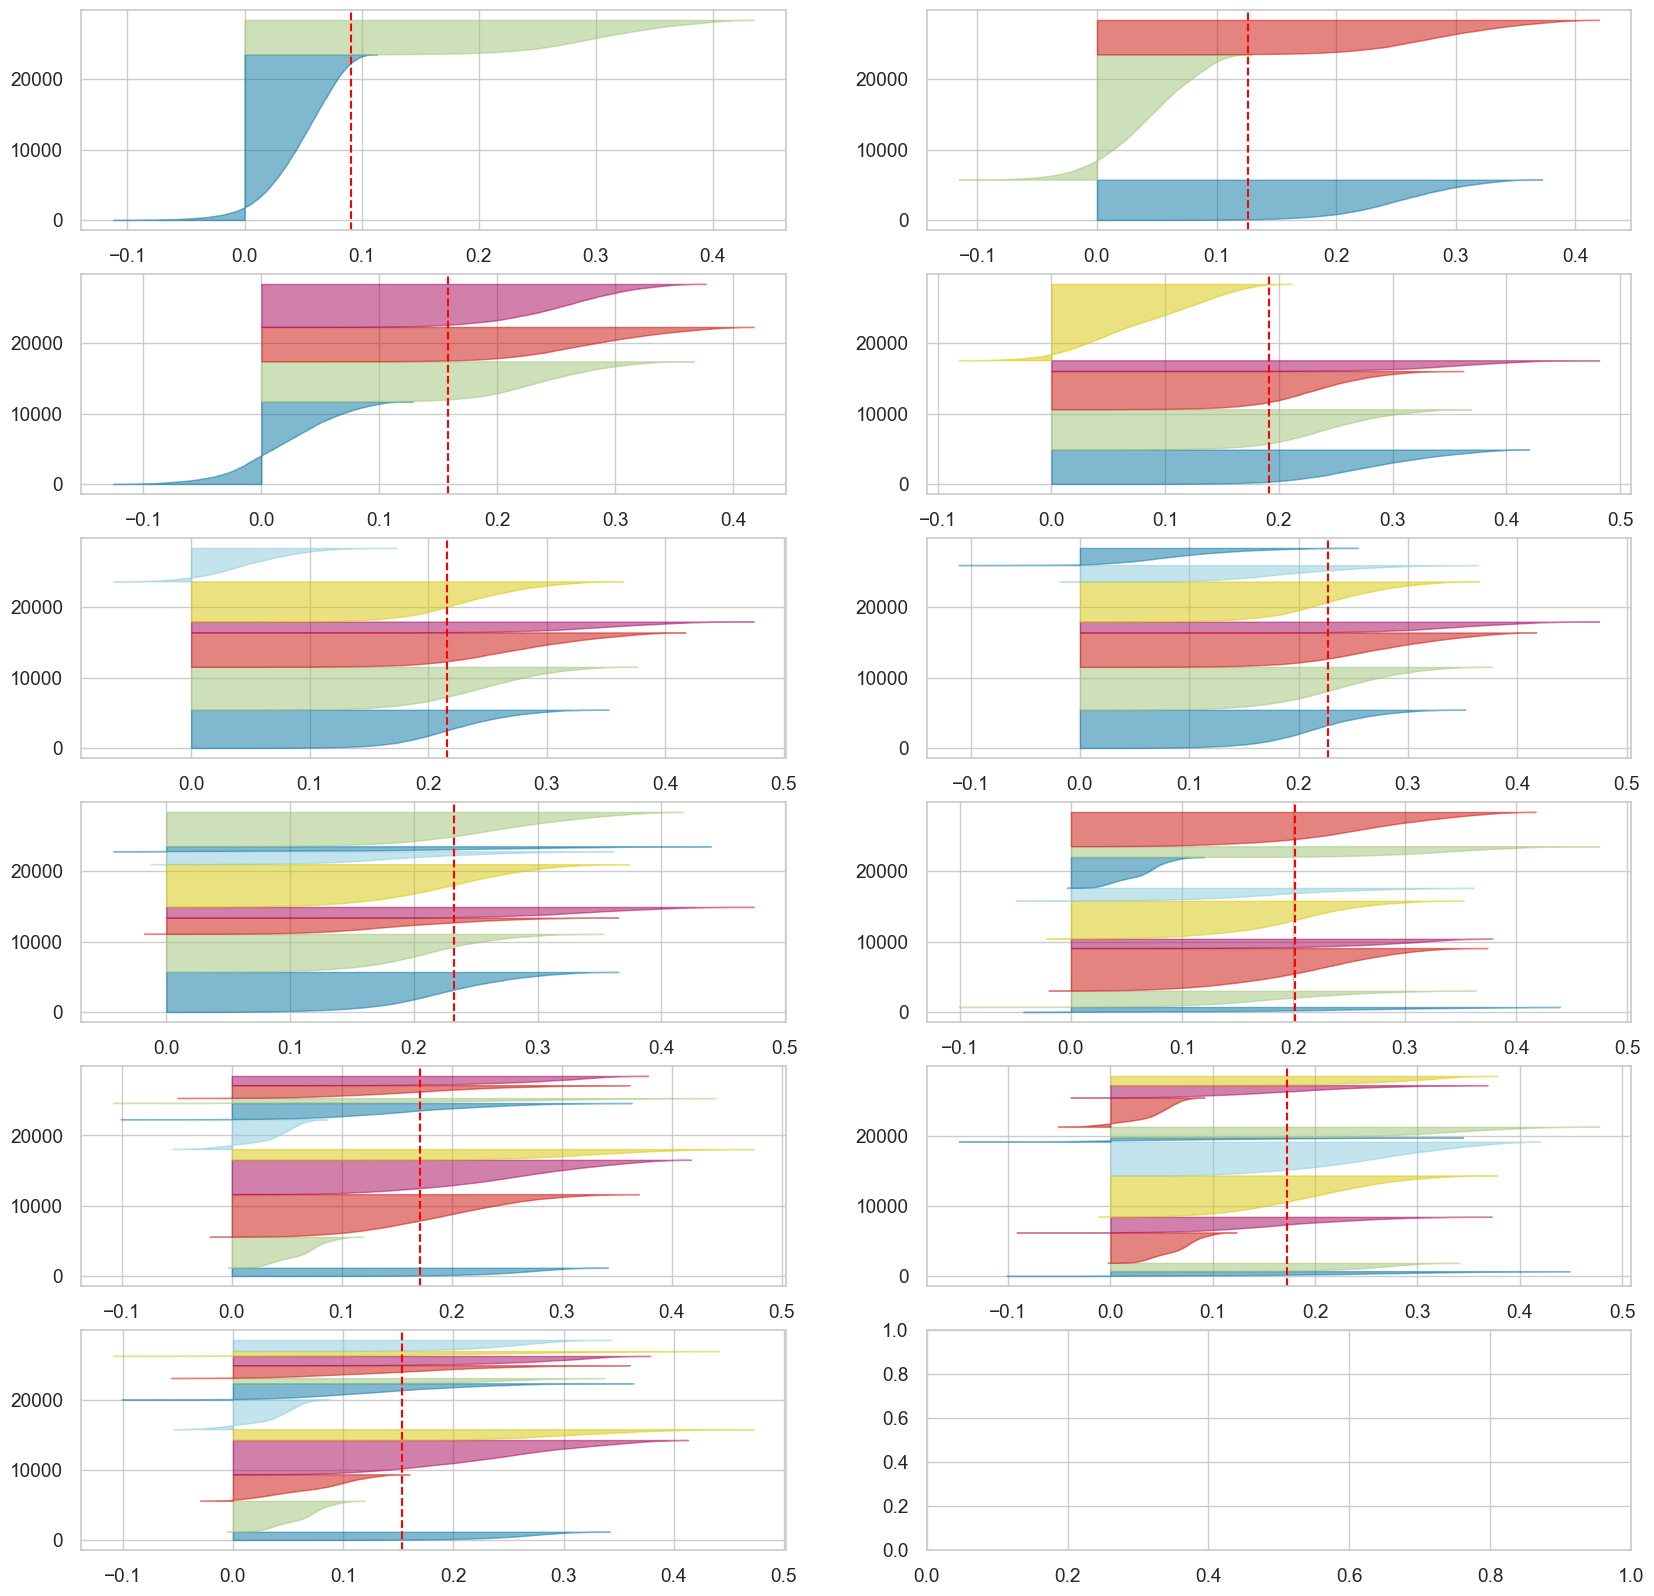

In [15]:
# Crosschecking Elbow Visualizer recommendation with silhouette score
k_values = range(2, 13)

for k in k_values:
    model = KMeans(k, random_state=42, n_init=12)
    model.fit(X_train)
    # Prediction of models
    Pred = model.predict(X_train)
    print("Silhouette Score for KMeans with k =", k, ":", silhouette_score(X_train, Pred))

# Plotting silhouette score for each cluster
fig, ax = plt.subplots(6, 2, figsize=(20, 20))    # 6 rows to fit k=2..12 (11 plots)

for i, k in enumerate(k_values):
    # Creat KMeans instances for different number of clusters
    km = KMeans(n_clusters=k, init='k-means++', n_init=12, max_iter=100, random_state=42)
    row, col = divmod(i, 2)    # Using enumerate index, not k itself
    # Create SilhouetteVisualizer instance with the KMeans & fit it
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[row][col])
    visualizer.fit(X_train)
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\silhouette_cluster_viz.png", dpi=150)
plt.show()

[2 5 6 ... 3 3 3]


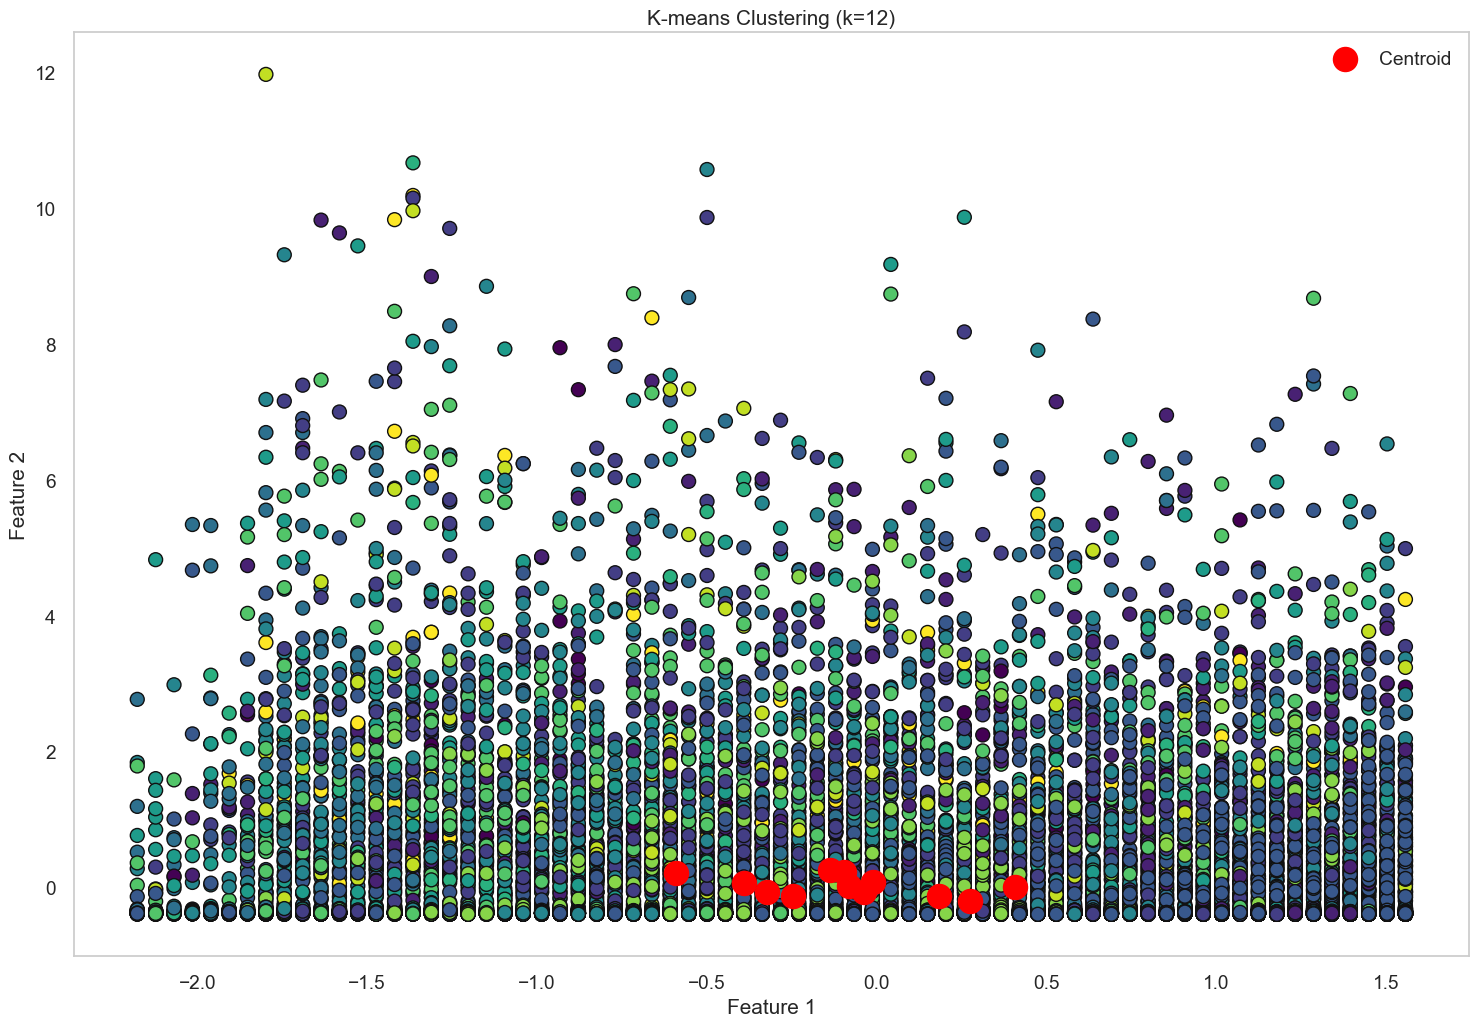

In [16]:
# Creating cluster grid 
k_values = range(2, 13)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_means = kmeans.fit_predict(X_train)

labels = kmeans.fit_predict(X_train.values)
print(labels)

# Convert X_train to NumPy array for indexing
X_train_array = X_train.values

plt.figure(figsize=(18, 12))

plt.scatter(X_train_array[:, 0], X_train_array[:, 1], c=y_means, cmap='viridis', 
            marker='o', edgecolor='k', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', label='Centroid', s=300)
plt.title(f"K-means Clustering (k={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()

plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\cluster_o_songs.png", dpi=150)
plt.show()

[2 5 6 ... 3 3 3]


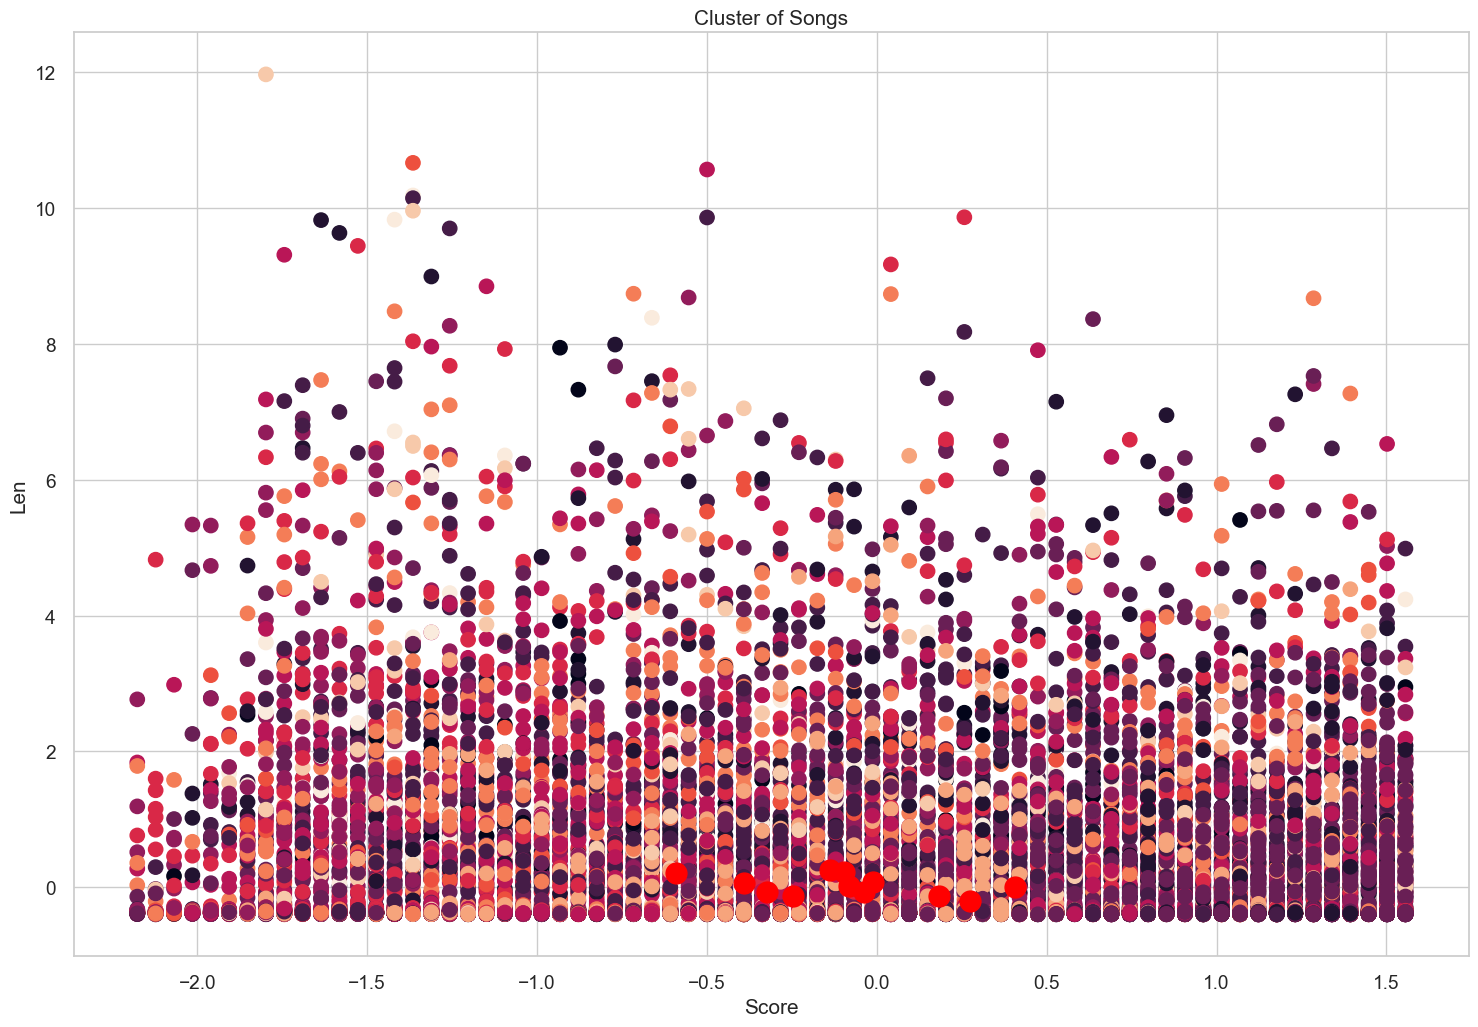

In [17]:
# Creating 2D cluster visual Elbow/Silhouette to help finalize decision

labels = kmeans.fit_predict(X_train.values)
print(labels)

kmeans.cluster_centers_

# Convert X_train to NumPy array for indexing
X_train_array = X_train.values

plt.figure(figsize=(18, 12))

plt.scatter(X_train_array[:, 0], X_train_array[:, 1], c=kmeans.labels_, s=106)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', s=225)
plt.title("Cluster of Songs")
plt.xlabel("Score")
plt.ylabel("Len")

plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\cluster2_o_songs.png", dpi=150)
plt.show()

##### *Elbow & Silhouette Insights*

abc

##### **<p style="text-align:center;">3B. Choosing Clusters</p>**    
Text here.

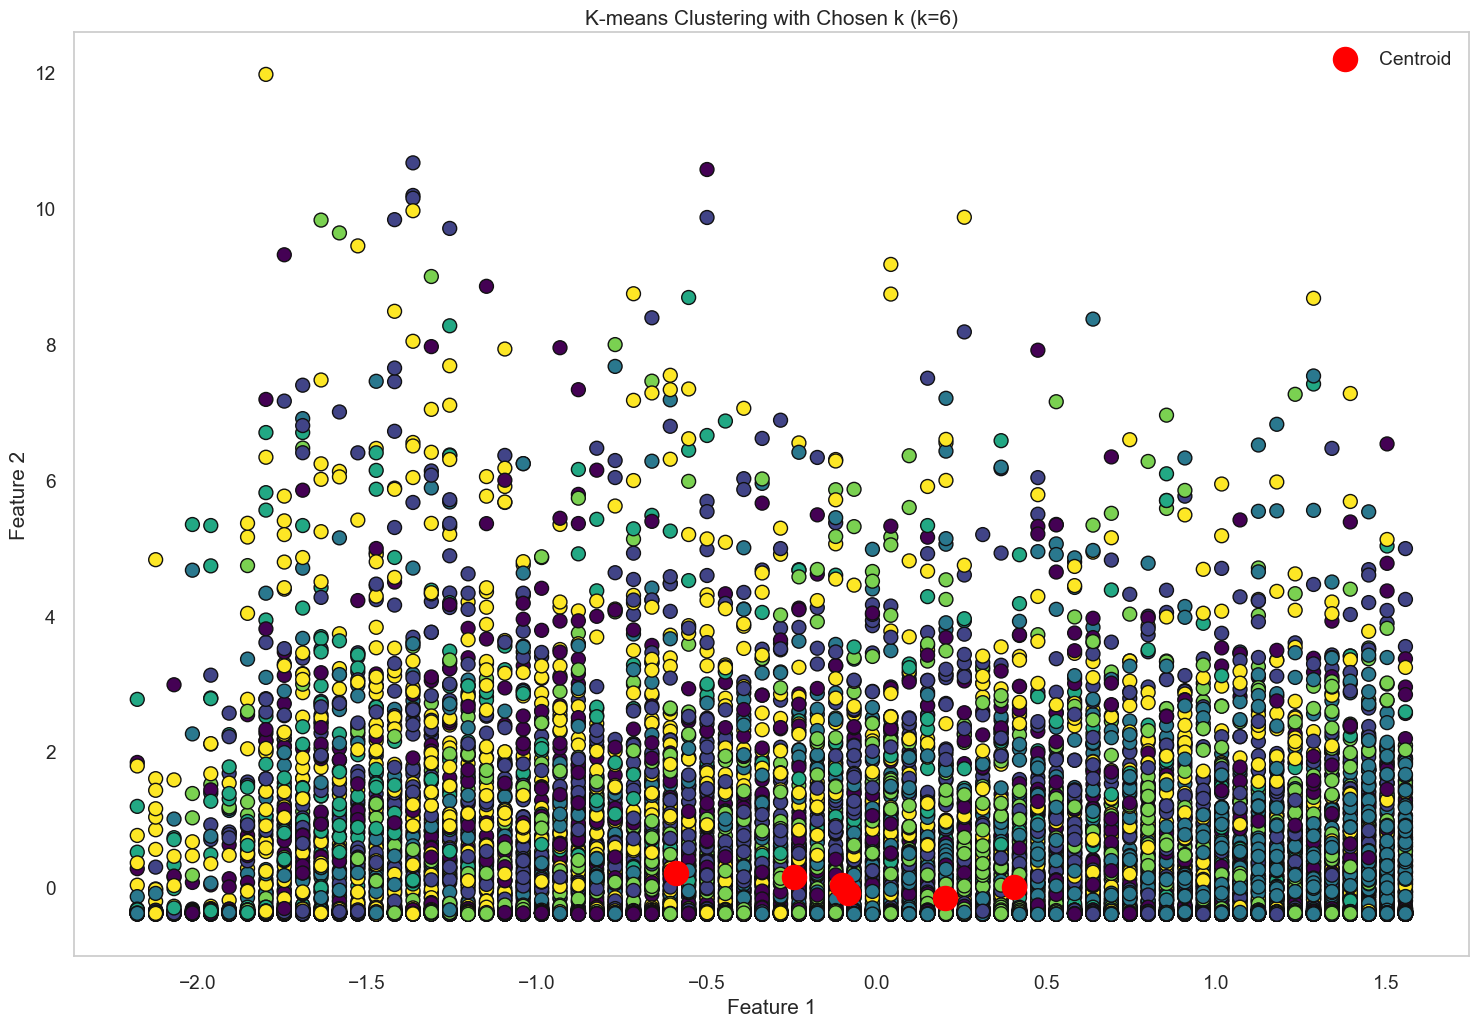

In [18]:
# Plotting specific chosen k
chosen_k = optimal_k  # from KneeLocator
km_plot = KMeans(n_clusters=chosen_k, init='k-means++', random_state=42)
y_means = km_plot.fit_predict(X_train)

# Convert X_train to NumPy array for indexing
X_train_array = X_train.values

plt.figure(figsize=(18, 12))

plt.scatter(X_train_array[:, 0], X_train_array[:, 1], c=y_means, cmap='viridis', 
            marker='o', edgecolor='k', s=100)
plt.scatter(km_plot.cluster_centers_[:, 0], km_plot.cluster_centers_[:, 1], 
            c='red', label='Centroid', s=300)
plt.title(f"K-means Clustering with Chosen k (k={chosen_k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()

plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\chosen_k_plt.png", dpi=150)
plt.show()

---
### **4. Modeling Music Features**

In [19]:
# Applying KMeans to the full scaled feature matrix to generate song clusters

kmeans_music = KMeans(n_clusters=optimal_k, random_state=42, n_init=12)
kmeans_music.fit(X_train)

# Storing results as 'songs': original data with cluster labels attached
songs = df_cl.copy()
songs['cluster'] = kmeans_music.labels_

print(f"KMeans fitted with k={optimal_k} clusters")
print(f"Cluster distribution:\n{songs['cluster'].value_counts().sort_index()}")
print(songs.head())

KMeans fitted with k=6 clusters
Cluster distribution:
cluster
0    5420
1    6096
2    4882
3    1524
4    5710
5    4740
Name: count, dtype: int64
   release_date    dating  violence  world_life  night_time  \
0      -2.17648 -0.391712 -0.305855   -0.699056   -0.507401   
1      -2.17648  0.275459 -0.120996    1.872639   -0.501275   
2      -2.17648 -0.350237 -0.647112   -0.686443   -0.487995   
3      -2.17648  0.518198 -0.653951   -0.693540   -0.498914   
4      -2.17648 -0.377363 -0.655062    1.723607   -0.500687   

   shake_the_audience  family_gospel  romantic  communication   obscene  ...  \
0           -0.413684       0.758051 -0.297631       1.707845 -0.532651  ...   
1           -0.396826       0.237390 -0.446751      -0.688320 -0.528870  ...   
2           -0.360278      -0.340172  1.035725       1.588406 -0.520671  ...   
3            0.100271      -0.369294  3.420147      -0.685907 -0.527412  ...   
4           -0.395207      -0.374023  3.909285      -0.687719 -0.528507  

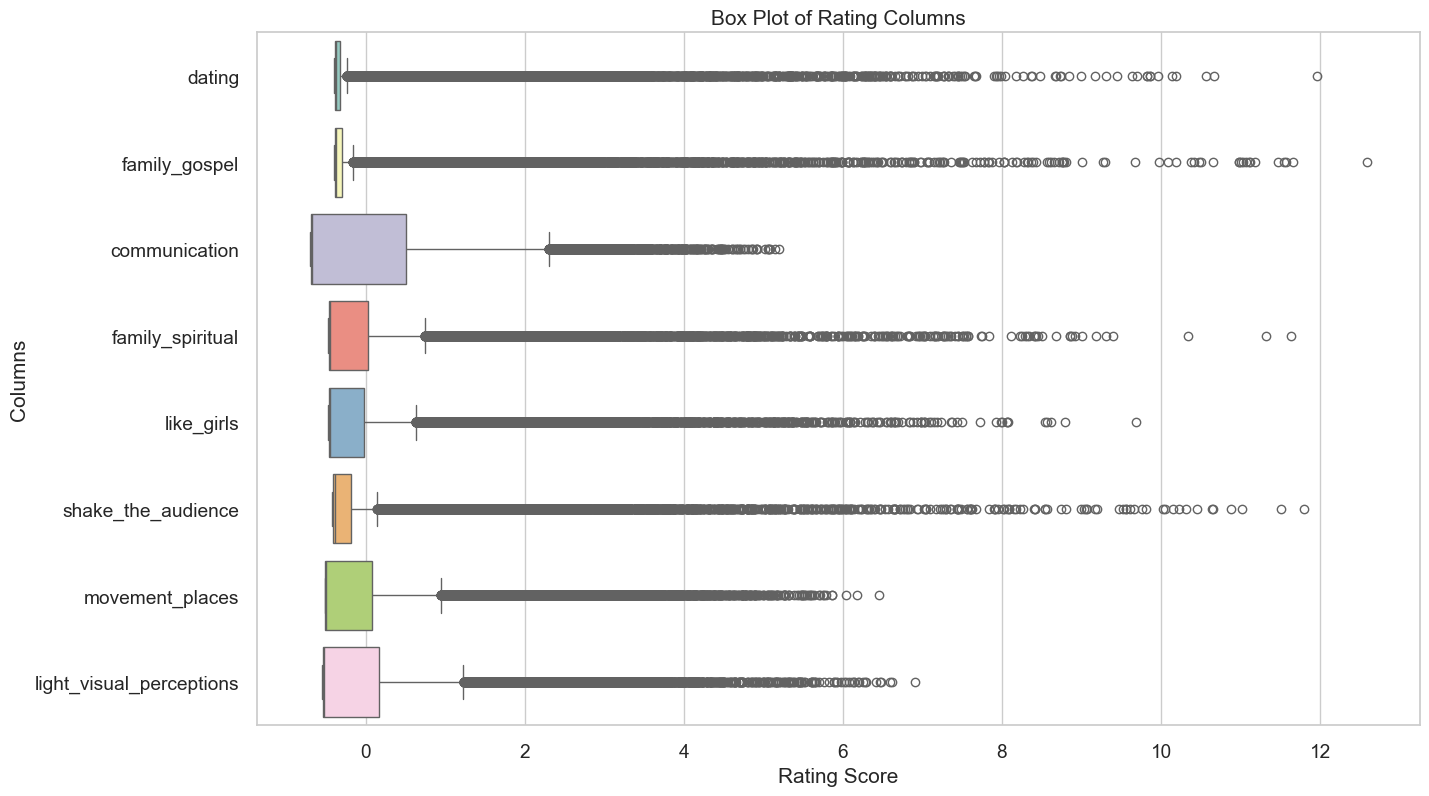

In [20]:
# Grouping rating columns together to represent music track attributes
rating = ['dating', 'family_gospel', 'communication', 'family_spiritual', 'like_girls', 
          'shake_the_audience', 'movement_places', 'light_visual_perceptions']

X = songs[rating]

# Box plot of rating columns
plt.figure(figsize=(15, 9))
sns.boxplot(data=songs[rating], orient='h', palette='Set3')
plt.title('Box Plot of Rating Columns')
plt.xlabel('Rating Score')
plt.ylabel('Columns')
plt.savefig("C:\\Users\\winni\\music-rec-algo\\Doc\\chosen_k_rating.png", dpi=150)
plt.show()

In [21]:
# Using sample of 10 unlabeled songs to see number of cluster generation
sample_songs = songs.sample(10, random_state=42)

selected_predictors = sample_songs[X_train.columns]
sample_labels = kmeans_music.predict(selected_predictors)

sample_songs = sample_songs.copy()
sample_songs['predicted_cluster'] = sample_labels
print(sample_songs[['cluster', 'predicted_cluster']])

       cluster  predicted_cluster
27369        1                  1
26302        4                  4
2325         5                  5
20415        1                  1
10154        5                  5
24074        1                  1
16045        1                  1
23163        4                  4
25097        4                  4
8147         5                  5


---
### **5. Update To Use Songs**

In [22]:
# Confirm no missing values remain
print("Missing values after cleaning:")
print(songs.isnull().sum())
print()

# Confirm shape is intact
print("\nDataFrame shape:\n", songs.shape)

# Numeric columns check
print("\nNumeric column stats:\n")
print(songs.describe())

Missing values after cleaning:
release_date                0
dating                      0
violence                    0
world_life                  0
night_time                  0
shake_the_audience          0
family_gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement_places             0
light_visual_perceptions    0
family_spiritual            0
like_girls                  0
sadness                     0
feelings                    0
genre_country               0
genre_jazz                  0
genre_pop                   0
genre_reggae                0
genre_rock                  0
topic_obscene               0
topic_romantic              0
topic_sadness               0
topic_violence              0
topic_world/life            0
cluster                     0
dtype: int64


DataFrame shape:
 (28372, 28)

Numeric column stats:

       release_date        dating      violence    world_lif

---
### **6. Save Songs CSV**

In [32]:
# Explicity noting path as being in Windows format so I can use forward slash
songs_path = PureWindowsPath("C:\\Users\Winni\\music-rec-algo\\Data\\songs_clustered.csv")

# Convert path to the correct format
file_path = Path(songs_path)

# Saving data as a DataFrame & index=False prevents pandas from saving row numbers as a column
songs.to_csv(file_path, index=False)

print("Songs cluster data saved successfully!")

AttributeError: 'PureWindowsPath' object has no attribute 'to_csv'

In [ ]:
# Most reliable confirmation is to reload saved file and review it
songs1 = PureWindowsPath("C:\\Users\\Winni\\music-rec-algo\\Data\\songs_clustered.csv")
file_path = Path(songs1)

songs1 = pd.read_csv(file_path)

print("Shape:", songs1.shape)
print("Missing values:\n", songs1.isnull().sum())
print("\nFinal columns:\n", songs1.columns.tolist())
print("\nPreview:\n", songs1.head(5))